# Практическое занятие №6: Синтез цифровых фильтров (КИХ и БИХ)

## Часть 1. Синтез КИХ-фильтров методом окон

### Задание 1.1. Проектирование ФНЧ с разными окнами
Спроектируйте КИХ-ФНЧ с частотой среза 200 Гц (частота дискретизации 1000 Гц), длина фильтра 51 отсчёт. Используйте окна:
- прямоугольное,
- Ханна,
- Хемминга,
- Блэкмана.

Постройте на одном графике АЧХ (в дБ) всех четырёх фильтров. Сравните:
- крутизну среза,
- уровень пульсаций в полосе пропускания и заграждения,
- ширину переходной полосы.


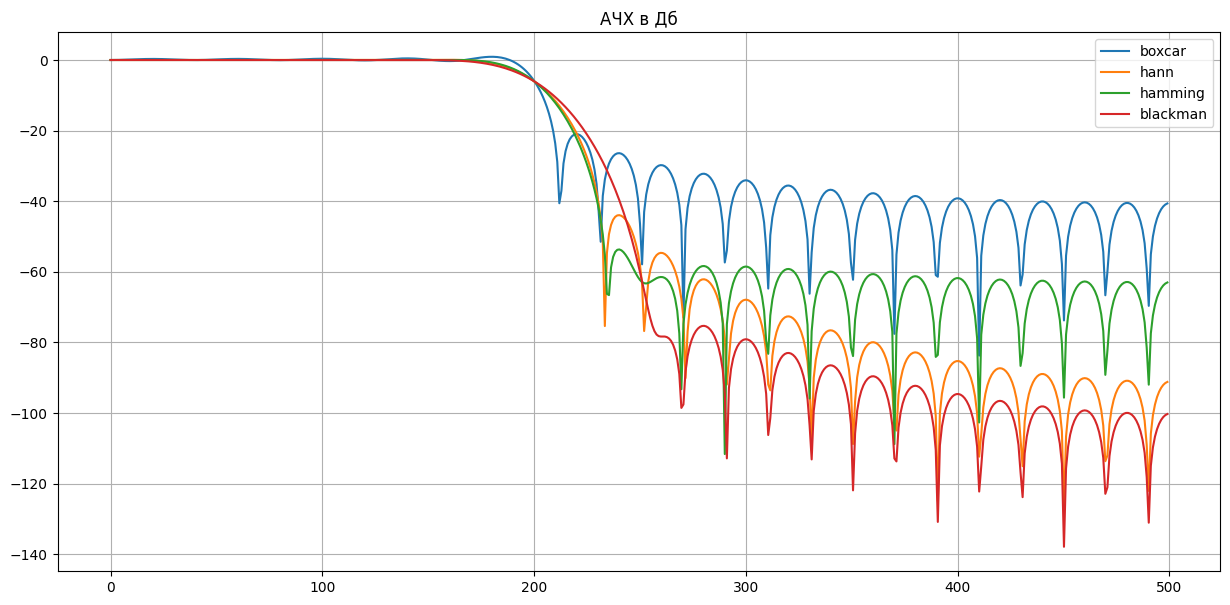

In [143]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
fs = 1000
L = 51
cutoff = 200

words = ['boxcar', 'hann', 'hamming', 'blackman']

plt.figure(figsize=(15, 7))
plt.title('АЧХ в Дб')

for word in words:
  h = scipy.signal.firwin(L, cutoff, window= word, fs=fs)

  w, H = scipy.signal.freqz(h, worN = 512, fs=fs)
  mag_dB = 20*np.log10(np.abs(H) + 1e-12)

  plt.plot(w ,mag_dB, label=f'{word}')
plt.grid()
plt.legend()
plt.show()

**Вопросы:** Какое окно обеспечивает наилучшее подавление в полосе заграждения? Какое – самую крутую переходную полосу? Как это связано с формой окна?

1) Окно Блэкмана

2) Прямоугольное окно.

3) Чем шире переходная полоса, тем меньше её крутизна. При увеличении крутизны среза ухудшается подавление в полосе заграждения.


### Задание 1.2. Влияние длины фильтра
Для окна Хемминга спроектируйте ФНЧ с fc=200 Гц, fs=1000 Гц, с длинами 21, 51, 101. Постройте АЧХ на одном графике.


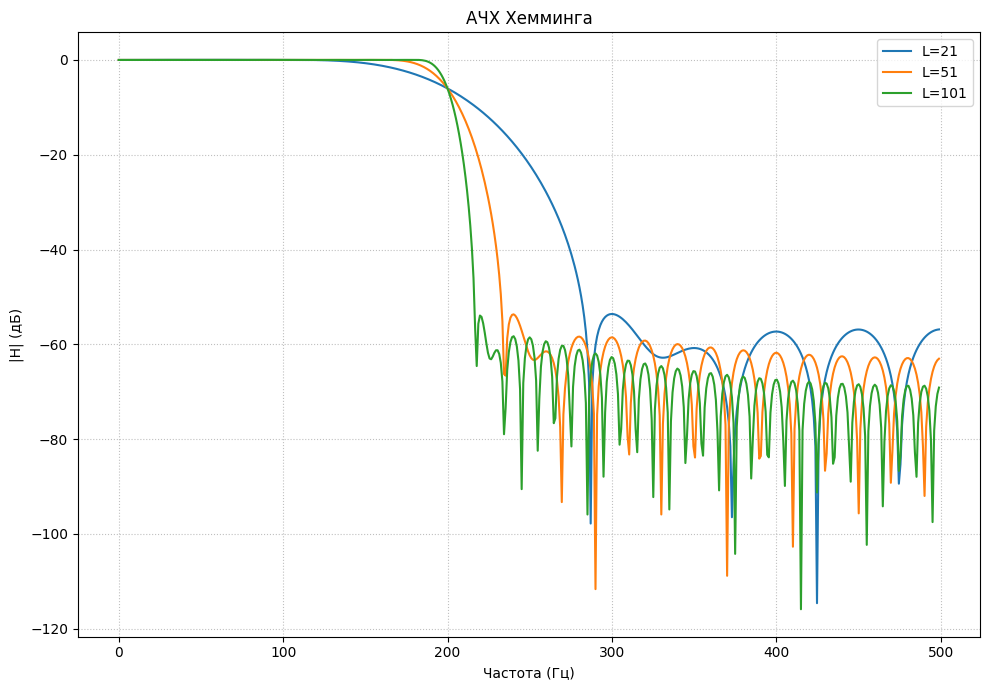

In [144]:
lengths = [21, 51, 101]
plt.figure(figsize=(10,7))
fc = 200
for L in lengths:
    b = signal.firwin(L, fc, fs=fs, window='hamming')
    w, H = signal.freqz(b, worN=512, fs=fs)
    plt.plot(w, 20*np.log10(np.abs(H)+1e-12), label=f'L={L}')
plt.title('АЧХ Хемминга')
plt.xlabel('Частота (Гц)')
plt.ylabel('|H| (дБ)')

plt.grid(True, which='both', linestyle=':', alpha=0.8)
plt.legend()
plt.tight_layout()
plt.show()

**Вопрос:** Как увеличение длины влияет на крутизну среза и на уровень боковых лепестков?

При увеличении длины фильтра переходная полоса сужается, срез становится круче, уровень боковых лепестков чуть-чуть уменьшается. Уровень боковых лепестков определяется не длиной, а типом окна


### Задание 1.3. Синтез ФВЧ и полосового фильтра методом окон
Используя тот же оконный метод, спроектируйте:
- ФВЧ с fc=200 Гц (длина 51, окно Хемминга);
- полосовой фильтр с полосой пропускания 200–300 Гц (длина 51, окно Хемминга).

Постройте АЧХ обоих фильтров.


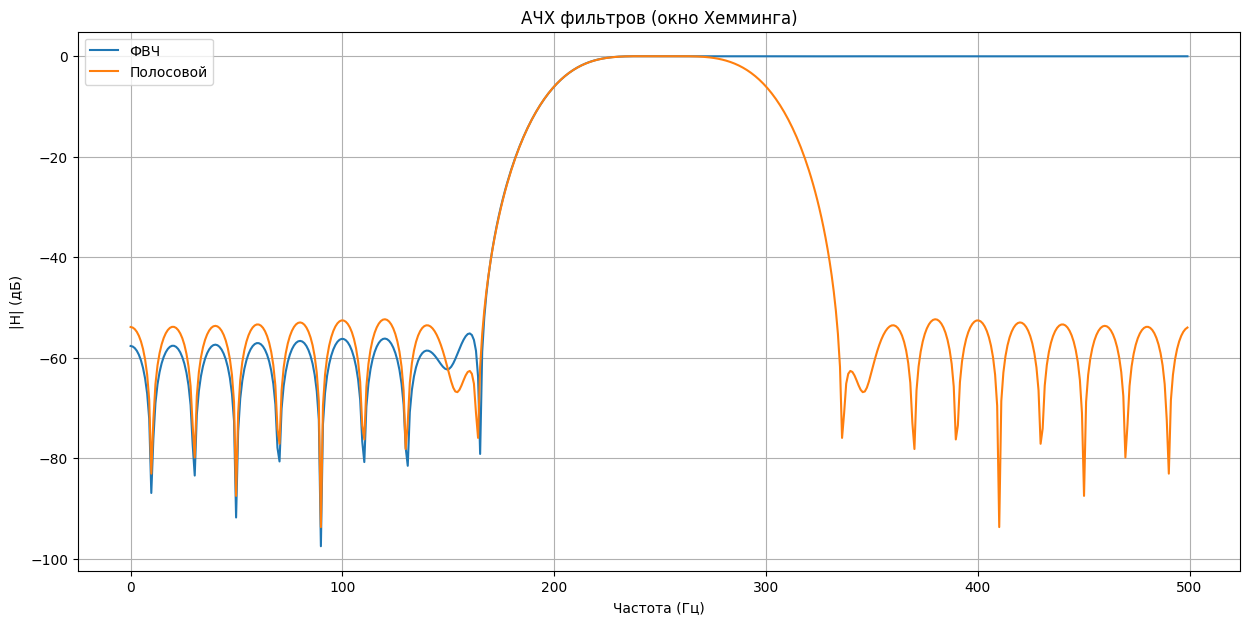

In [147]:
b_hp = signal.firwin(51, cutoff, fs=fs, window='hamming', pass_zero='highpass')
b_bp = signal.firwin(51, [200, 300], fs=fs, window='hamming', pass_zero='bandpass')

w, H_hp = signal.freqz(b_hp, 1, fs=fs)
w, H_bp = signal.freqz(b_bp, 1, fs=fs)

plt.figure(figsize=(15, 7))
plt.plot(w, 20*np.log10(np.abs(H_hp)+1e-12), label='ФВЧ')
plt.plot(w, 20*np.log10(np.abs(H_bp)+1e-12), label='Полосовой')
plt.title('АЧХ фильтров (окно Хемминга)')
plt.xlabel('Частота (Гц)')
plt.ylabel('|H| (дБ)')
plt.grid()
plt.legend()
plt.show()

Подайте на спроектированные фильтры сигнал: сумма синусоид 100, 250 и 350 Гц (амплитуды 1, 0.8, 0.6). Постройте спектры до и после фильтрации (в логарифмическом масштабе).

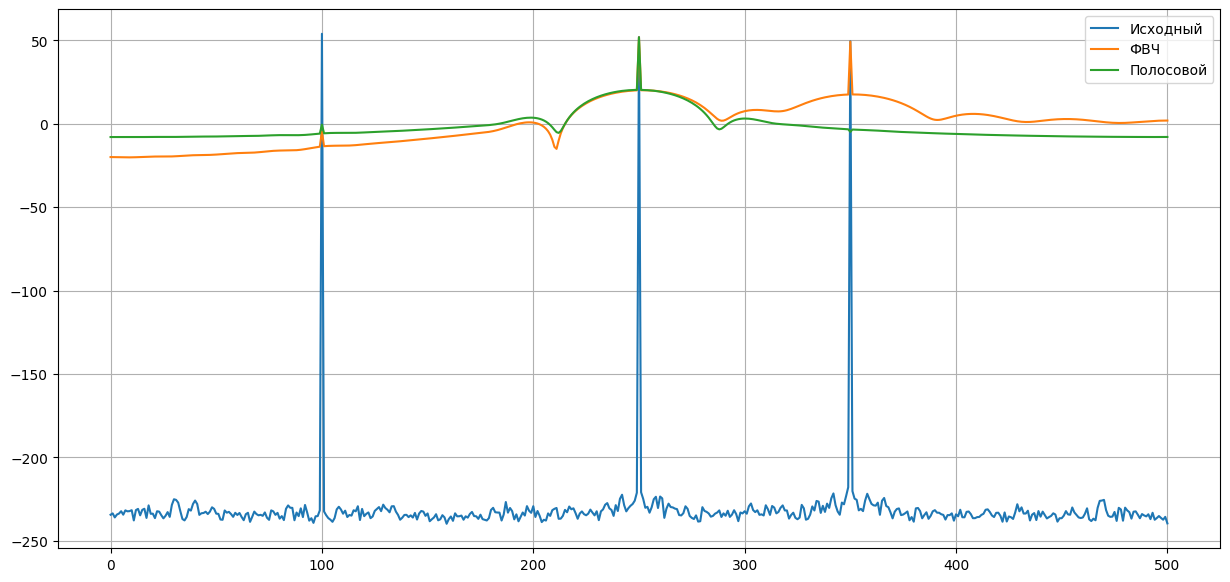

In [148]:
t = np.arange(0, 1, 1/fs)
a1 = 1; a2 = 0.8; a3 = 0.6
b1 = 100; b2 = 250; b3 = 350
sin1 = a1*np.sin(2*np.pi*b1*t)
sin2 = a2*np.sin(2*np.pi*b2*t)
sin3 = a3*np.sin(2*np.pi*b3*t)
sig = sin1 + sin2 + sin3
y_hp = signal.lfilter(b_hp, 1, sig)
y_bp = signal.lfilter(b_bp, 1, sig)

X = np.fft.rfft(sig)
x_orig = 20 * np.log10(np.abs(X) + 1e-12)
freq = np.fft.rfftfreq(len(sig), 1/fs)

y_hp = np.fft.rfft(signal.lfilter(b_hp, 1, sig))
y_bp = np.fft.rfft(signal.lfilter(b_bp, 1, sig))
y_f = 20 * np.log10(np.abs(y_hp) + 1e-12)
y_p = 20 * np.log10(np.abs(y_bp) + 1e-12)

plt.figure(figsize=(15, 7))
plt.plot(freq, x_orig, label = 'Исходный')
plt.plot(freq, y_f, label = 'ФВЧ')
plt.plot(freq, y_p, label = 'Полосовой')
plt.grid()
plt.legend()
plt.show()

**Вопрос:** Объясните полученные результаты.

ФВЧ подавляет частоту в 100 Гц и пропускает 250 и 350 Гц, потому что он стоит с 200 Гц. Полосовой фильтр 200–300 Гц оставляет 250 Гц и подавляет 100 Гц и 350 Гц.


## Часть 2. Равноволновой синтез КИХ-фильтров (Паркса–МакКлеллана)

### Задание 2.1. Проектирование оптимального ФНЧ
Используя `signal.remez`, спроектируйте ФНЧ с параметрами:
- частота дискретизации 1000 Гц,
- полоса пропускания 0–150 Гц,
- полоса заграждения 250–500 Гц,
- длина фильтра 21.

Постройте АЧХ (в линейном и логарифмическом масштабах) и сравните её с АЧХ КИХ-фильтра, полученного методом окон (окно Хемминга, та же длина, fc=200 Гц).

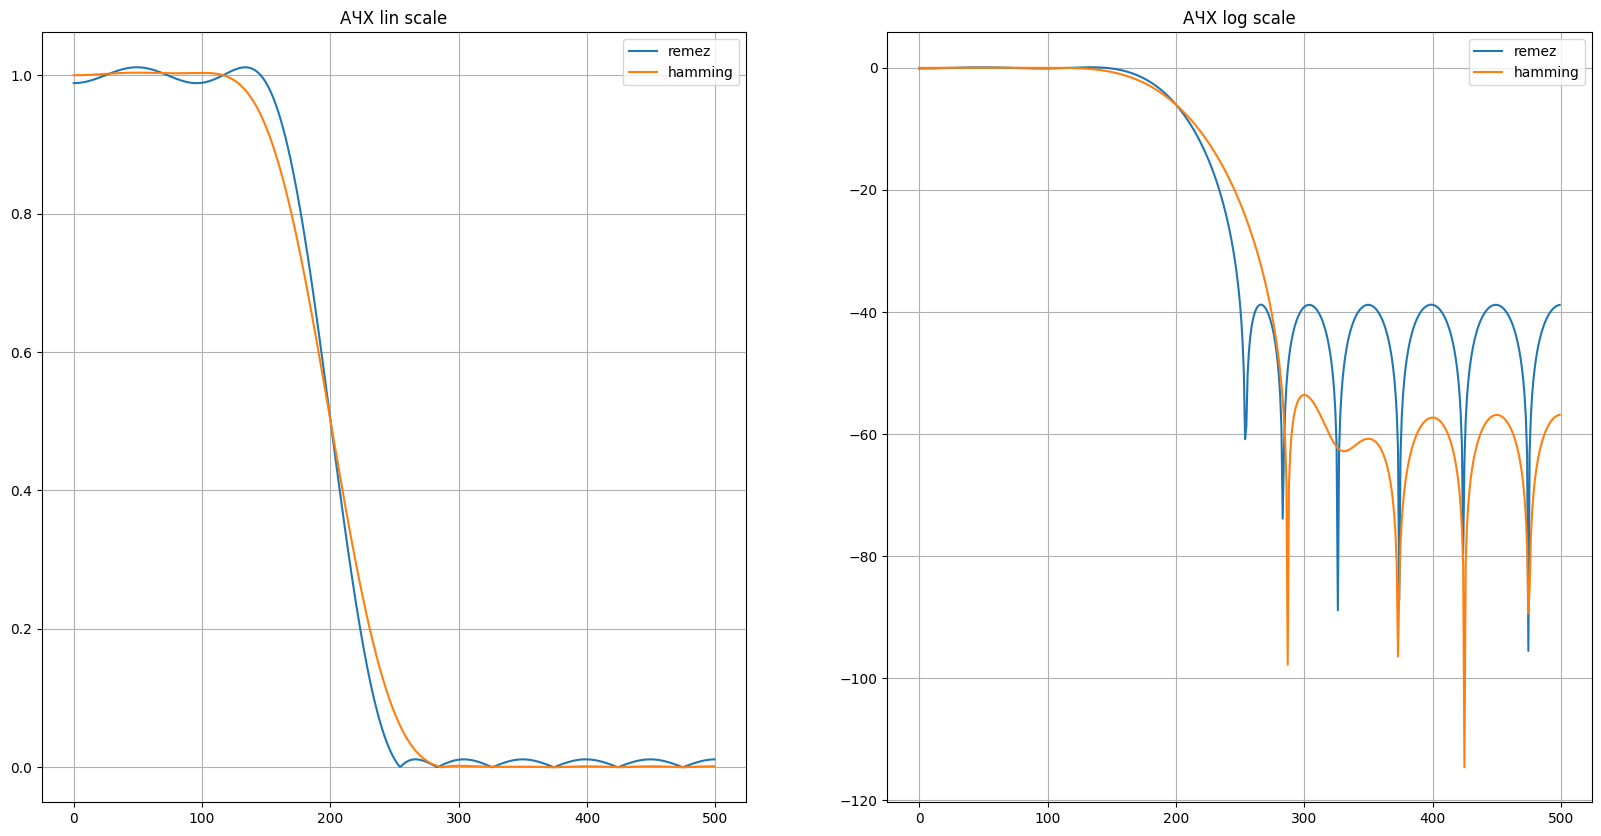

In [149]:
b_remez = signal.remez(21, [0, 150, 250, 500], [1, 0], fs=fs)
b_hamming = signal.firwin(21, 200, fs=fs, window='hamming')

w_rem, H_rem = signal.freqz(b_remez, 1, fs=fs)
w_ham, H_ham = signal.freqz(b_hamming, 1, fs=fs)

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.title('АЧХ lin scale')
plt.plot(w_rem, np.abs(H_rem), label = 'remez')
plt.plot(w_ham, np.abs(H_ham), label = 'hamming')
plt.legend()
plt.grid()

H_rem_db = 20 * np.log10(np.abs(H_rem) + 1e-12)
H_ham_db = 20 * np.log10(np.abs(H_ham)+ 1e-12)

plt.subplot(1, 2, 2)
plt.title('АЧХ log scale')
plt.plot(w_rem, H_rem_db, label = 'remez')
plt.plot(w_ham, H_ham_db, label = 'hamming')
plt.grid()
plt.legend()
plt.show()


**Вопросы:** Какой фильтр имеет более крутой срез? Каковы пульсации в полосе пропускания?

У фильтра Ремеза более крутой срез, но его пульсации равномернее. У фильтра Хемминга пульсации значительно больше

### Задание 2.2. Зависимость от ширины переходной полосы

Поменяйте верхнюю частоту полосы пропускания и нижнюю частоту полосы заграждения так, чтобы их среднее оставалось равным 200 Гц. Постройте АЧХ получившегося фильтра. Подберите ширину переходной области (разности нижней частоты полосы заграждения и верхней частоты полосы пропускания) так, чтобы уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга.


Подавление окна Хемминга на 300 Гц: -53.59 дБ


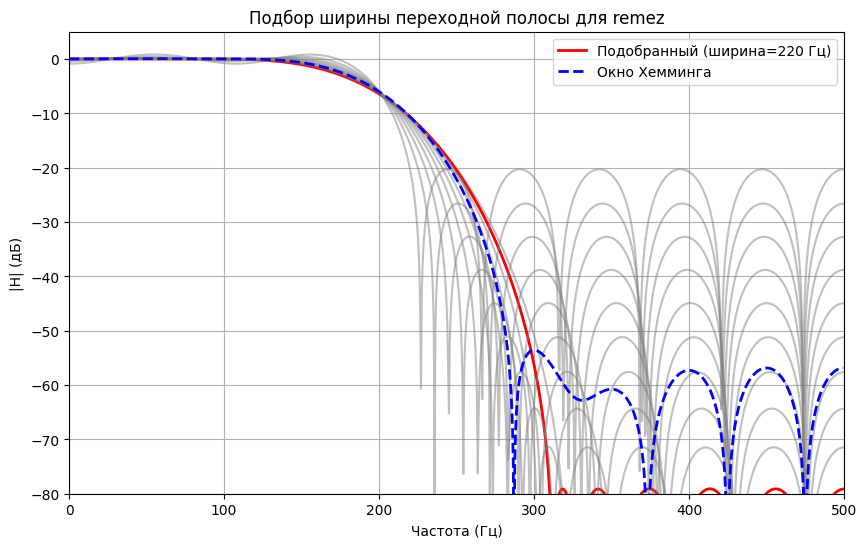

Подобранная ширина переходной полосы: 220 Гц (полосы [90, 310])
Подавление на 300 Гц: -53.59 дБ (совпало с Хеммингом)


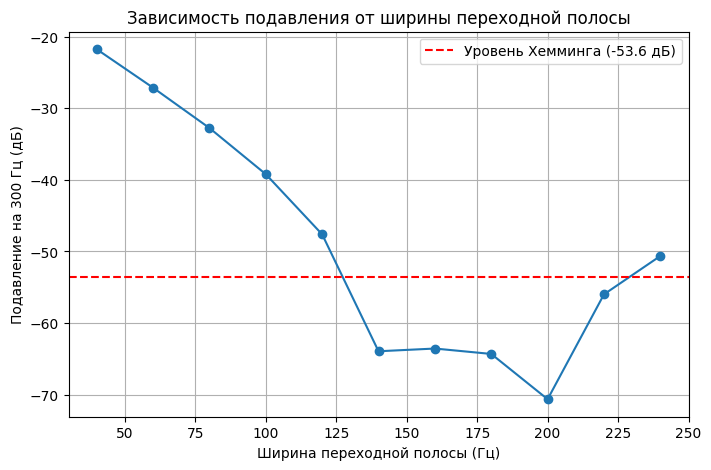

In [182]:
L = 21
fc_hamm = 200
h_hamm = signal.firwin(L, fc_hamm, window='hamming', fs=fs)

w, H_hamm = signal.freqz(h_hamm, 1, worN=1024, fs=fs)
idx_300 = np.argmin(np.abs(w - 300))
target_suppress = 20*np.log10(np.abs(H_hamm[idx_300]) + 1e-12)
print(f'Подавление окна Хемминга на 300 Гц: {target_suppress:.2f} дБ')

centers = []
suppressions = []
best_width = None
best_h = None
best_bands = None

plt.figure(figsize=(10, 6))
for low_end in range(80, 181, 10):
    high_start = 400 - low_end
    if high_start <= low_end:
        continue
    h_test = signal.remez(L, [0, low_end, high_start, 500], [1, 0], fs=fs)
    w, H_test = signal.freqz(h_test, 1, worN=1024, fs=fs)
    suppr = 20*np.log10(np.abs(H_test[idx_300]) + 1e-12)
    centers.append((low_end + high_start)/2)
    suppressions.append(suppr)
    plt.plot(w, 20*np.log10(np.abs(H_test)+1e-12), 'gray', alpha=0.5)
    if suppr <= target_suppress and best_width is None:
        best_width = high_start - low_end
        best_h = h_test
        best_bands = (low_end, high_start)
        plt.plot(w, 20*np.log10(np.abs(H_test)+1e-12), 'r', linewidth=2, label=f'Подобранный (ширина={best_width} Гц)')

plt.plot(w, 20*np.log10(np.abs(H_hamm)+1e-12), 'b--', linewidth=2, label='Окно Хемминга')
plt.title('Подбор ширины переходной полосы для remez')
plt.xlabel('Частота (Гц)')
plt.ylabel('|H| (дБ)')
plt.legend()
plt.grid()
plt.ylim(-80, 5)
plt.xlim(0, 500)
plt.show()

if best_width is not None:
    print(f'Подобранная ширина переходной полосы: {best_width} Гц (полосы [{best_bands[0]}, {best_bands[1]}])')
    print(f'Подавление на 300 Гц: {target_suppress:.2f} дБ (совпало с Хеммингом)')
else:
    print('Не удалось достичь подавления окна Хемминга при L=21, нужно увеличить длину фильтра.')

plt.figure(figsize=(8,5))
widths = [400 - 2*low for low in range(80,181,10) if (400 - low) > low]
widths = [400 - 2*low for low in range(80,181,10) if (400 - low) > low]
plt.plot(widths, suppressions, 'o-')
plt.axhline(y=target_suppress, color='r', linestyle='--', label=f'Уровень Хемминга ({target_suppress:.1f} дБ)')
plt.xlabel('Ширина переходной полосы (Гц)')
plt.ylabel('Подавление на 300 Гц (дБ)')
plt.title('Зависимость подавления от ширины переходной полосы')
plt.grid()
plt.legend()
plt.show()

**Вопрос:** При какой ширине переходной области уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга?

Получилось около 100 Гц. С 125 Гц до 225 Гц

### Задание 2.3. Управление весами
Для фильтра из задачи 2.1 измените весовые коэффициенты: задайте `weight=[1, 10]` (увеличить вес для полосы заграждения). Постройте новую АЧХ и сравните с предыдущей.


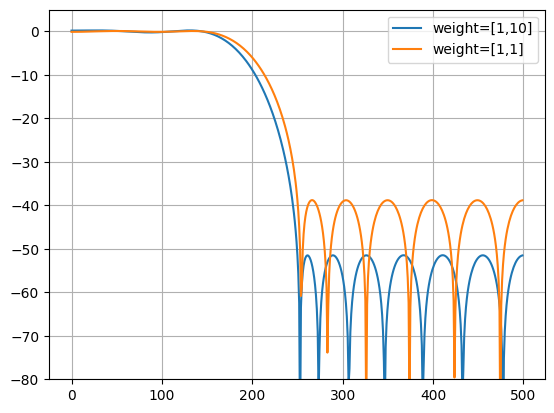

In [109]:
b_remez_w = signal.remez(21, [0, 150, 250, 500], [1, 0], weight=[1, 10], fs=fs)
w, H_w = signal.freqz(b_remez_w, 1, fs=fs)
plt.plot(w, 20*np.log10(np.abs(H_w)+1e-12), label='weight=[1,10]')
plt.plot(w, 20*np.log10(np.abs(H_rem)+1e-12), label='weight=[1,1]')
plt.legend(), plt.grid(), plt.ylim(-80,5)
plt.show()

**Вопрос:** Как изменилось подавление в полосе заграждения и пульсации в полосе пропускания?

При увеличении веса увеличилось и подавление сигнала. Пульсации стали другими(увеличение)

### Задание 2.4. Сравнение КИХ-фильтров на реальном сигнале
Сгенерируйте сигнал: смесь синусоид 50 Гц, 120 Гц, 220 Гц (амплитуды 1, 0.7, 0.3) + белый шум (дисперсия 0.1), fs=1000 Гц. Пропустите этот сигнал через:
- КИХ-ФНЧ спроектированный методом окон (окно Хемминга, длина 51, fc=150 Гц);
- КИХ-ФНЧ спроектированный методом `remez` (длина 51, полоса пропускания 0–100 Гц, полоса заграждения 200–500 Гц).

Постройте спектры исходного и отфильтрованных сигналов в линейном и логарифмическом масштабе.


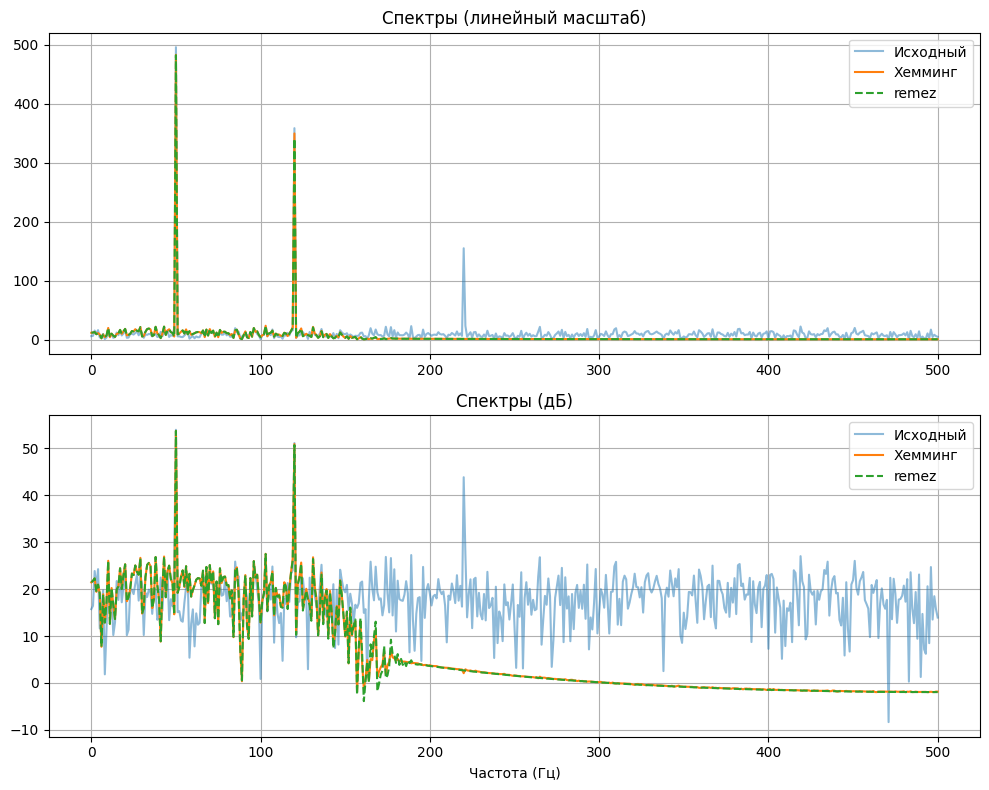

In [173]:
L = 51
np.random.seed(42)
t = np.arange(0, 1, 1/fs)
x_clean = np.sin(2*np.pi*50*t) + 0.7*np.sin(2*np.pi*120*t) + 0.3*np.sin(2*np.pi*220*t)
noise = np.sqrt(0.1)*np.random.randn(len(t))
x_noisy = x_clean + noise

h_hamm51 = signal.firwin(51, 150, window='hamming', fs=fs)
h_remez51 = signal.remez(51, [0,100,200,500], [1,0], fs=fs)

y_hamm = signal.lfilter(h_hamm51, 1, x_noisy)
y_remez = signal.lfilter(h_remez51, 1, x_noisy)

X = np.fft.rfft(x_noisy)
Yh = np.fft.rfft(y_hamm)
Yr = np.fft.rfft(y_remez)
freq = np.fft.rfftfreq(len(x_noisy), 1/fs)

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(freq, np.abs(X), alpha=0.5, label='Исходный')
plt.plot(freq, np.abs(Yh), label='Хемминг')
plt.plot(freq, np.abs(Yr), '--', label='remez')
plt.title('Спектры (линейный масштаб)')
plt.legend(), plt.grid()

plt.subplot(2,1,2)
plt.plot(freq, 20*np.log10(np.abs(X)+1e-12), alpha=0.5, label='Исходный')
plt.plot(freq, 20*np.log10(np.abs(Yh)+1e-12), label='Хемминг')
plt.plot(freq, 20*np.log10(np.abs(Yr)+1e-12), '--', label='remez')
plt.title('Спектры (дБ)')
plt.xlabel('Частота (Гц)')
plt.legend(), plt.grid()
plt.tight_layout()
plt.show()


**Вопросы:** Какой фильтр лучше подавил 220 Гц и шум? Какой лучше сохранил 120 Гц? На сколько отличаются амплитуды 120 Гц сигнала от исходных для каждого из фильтров?


220 Гц и шум лучше подавил ремез. Фильтр Хемминга лучше сохранил 120Гц. Отличие амплитуды 120 гЦ сигнала для Хемминга 11.5, для Ремеза 20.

## Часть 3. Синтез БИХ-фильтров

### Задание 3.1. Баттерворт, Чебышев, эллиптический – сравнение АЧХ
Спроектируйте ФНЧ с частотой среза 200 Гц (fs=1000 Гц) следующих типов (порядок 4):
- Баттерворт (`butter`);
- Чебышев I с пульсациями 1 дБ (`cheby1`);
- Чебышев II с затуханием 40 дБ в полосе заграждения (`cheby2`);
- Эллиптический с пульсациями 1 дБ и затуханием 40 дБ (`ellip`).

Постройте АЧХ всех фильтров на одном графике (в дБ). Сравните:
- крутизну среза,
- пульсации в полосе пропускания и заграждения.

Постройте и сравните фазовые характеристики (ФЧХ) и групповые задержки.


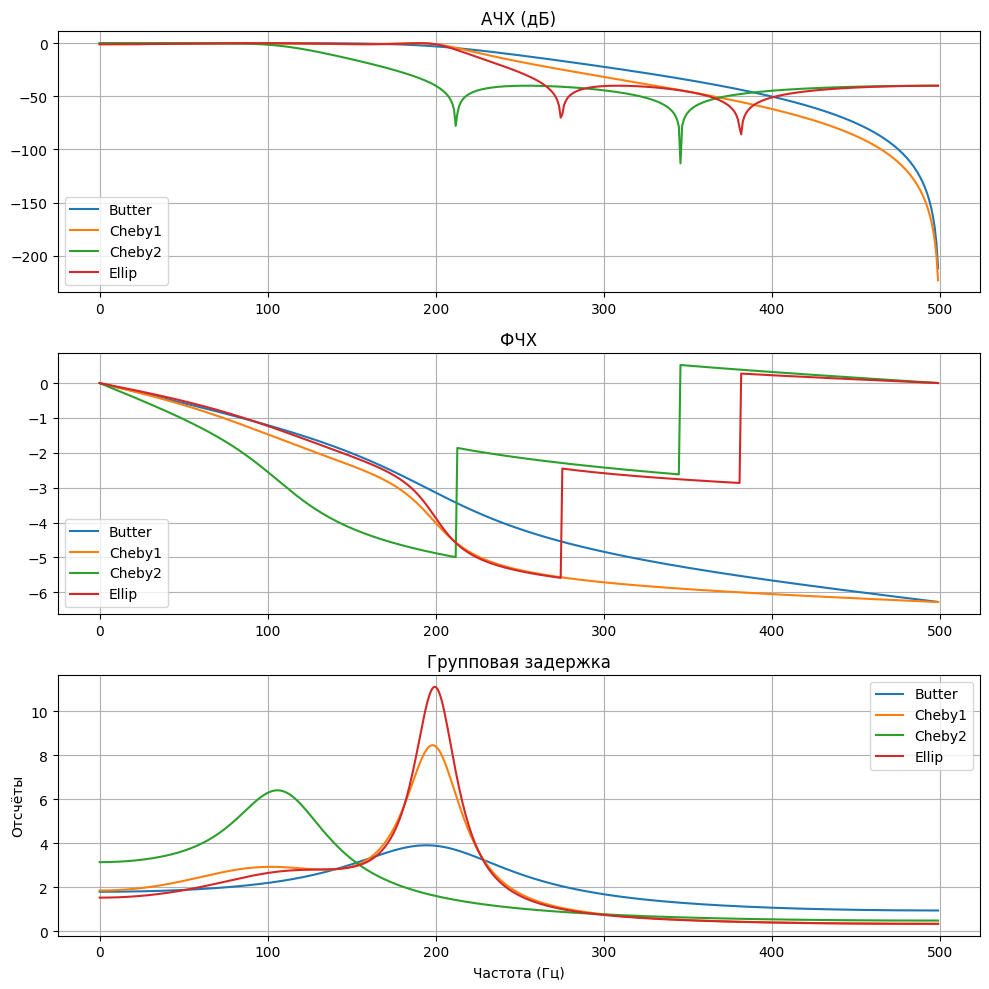

In [177]:
N = 4
Wn = 200
rp, rs = 1, 40
b_but, a_but = signal.butter(N, Wn, btype='low', fs=fs)
b_che1, a_che1 = signal.cheby1(N, rp, Wn, btype='low', fs=fs)
b_che2, a_che2 = signal.cheby2(N, rs, Wn, btype='low', fs=fs)
b_ell, a_ell = signal.ellip(N, rp, rs, Wn, btype='low', fs=fs)

w, H_but = signal.freqz(b_but, a_but, fs=fs)
_, H_che1 = signal.freqz(b_che1, a_che1, fs=fs)
_, H_che2 = signal.freqz(b_che2, a_che2, fs=fs)
_, H_ell = signal.freqz(b_ell, a_ell, fs=fs)

plt.figure(figsize=(10,10))
plt.subplot(3,1,1)
plt.plot(w, 20*np.log10(np.abs(H_but)+1e-12), label='Butter')
plt.plot(w, 20*np.log10(np.abs(H_che1)+1e-12), label='Cheby1')
plt.plot(w, 20*np.log10(np.abs(H_che2)+1e-12), label='Cheby2')
plt.plot(w, 20*np.log10(np.abs(H_ell)+1e-12), label='Ellip')
plt.title('АЧХ (дБ)')
plt.legend(), plt.grid()

plt.subplot(3,1,2)
plt.plot(w, np.unwrap(np.angle(H_but)), label='Butter')
plt.plot(w, np.unwrap(np.angle(H_che1)), label='Cheby1')
plt.plot(w, np.unwrap(np.angle(H_che2)), label='Cheby2')
plt.plot(w, np.unwrap(np.angle(H_ell)), label='Ellip')
plt.title('ФЧХ')
plt.legend(), plt.grid()

plt.subplot(3,1,3)
w_g, gd_but = signal.group_delay((b_but, a_but), fs=fs)
_, gd_che1 = signal.group_delay((b_che1, a_che1), fs=fs)
_, gd_che2 = signal.group_delay((b_che2, a_che2), fs=fs)
_, gd_ell = signal.group_delay((b_ell, a_ell), fs=fs)
plt.plot(w_g, gd_but, label='Butter')
plt.plot(w_g, gd_che1, label='Cheby1')
plt.plot(w_g, gd_che2, label='Cheby2')
plt.plot(w_g, gd_ell, label='Ellip')
plt.title('Групповая задержка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Отсчёты')
plt.legend(), plt.grid()
plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр даёт самый крутой спад? Какой имеет наименьшие фазовые искажения в полосе пропускания?


Эллиптический фильтр - самый крутой спад.

Наименьшие фазовые искажения у Баттерворта

### Задание 3.2. Влияние порядка на характеристики БИХ-фильтра
Для фильтра Баттерворта с fc=200 Гц, fs=1000 Гц возьмите порядки 2, 4, 6. Постройте АЧХ и групповую задержку.


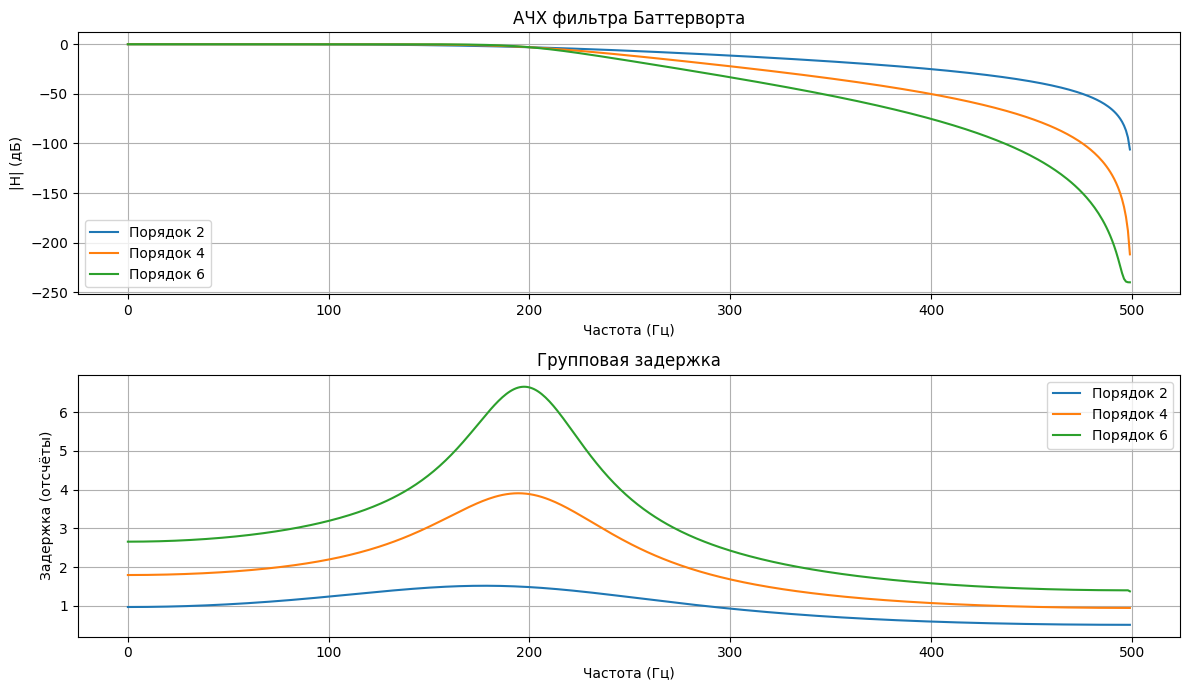

In [172]:
orders = [2, 4, 6]
Wn = 200
fs = 1000

plt.figure(figsize=(12, 7))

plt.subplot(2, 1, 1)
for N in orders:
    b, a = signal.butter(N, Wn, btype='low', fs=fs)
    w, H = signal.freqz(b, a, worN=512, fs=fs)
    plt.plot(w, 20*np.log10(np.abs(H) + 1e-12), label=f'Порядок {N}')
plt.title('АЧХ фильтра Баттерворта')
plt.xlabel('Частота (Гц)')
plt.ylabel('|H| (дБ)')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
for N in orders:
    b, a = signal.butter(N, Wn, btype='low', fs=fs)
    w_gd, gd = signal.group_delay((b, a), fs=fs)
    plt.plot(w_gd, gd, label=f'Порядок {N}')
plt.title('Групповая задержка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (отсчёты)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

**Вопросы:** Как увеличение порядка влияет на крутизну среза и на групповую задержку в полосе пропускания?

Чем выше порядок, тем круче срез и тем больше групповая задержка

### Задание 3.3. Преобразование типа БИХ-фильтра (ФНЧ → ФВЧ, полосовой)
Спроектируйте Баттерворта 4-го порядка:
- ФНЧ с fc=200 Гц;
- ФВЧ с fc=200 Гц (используйте `btype='high'`);
- полосовой с полосой 200–300 Гц.

Подайте на них сигнал: сумма синусоид 100, 250, 400 Гц. Постройте спектры после фильтрации.


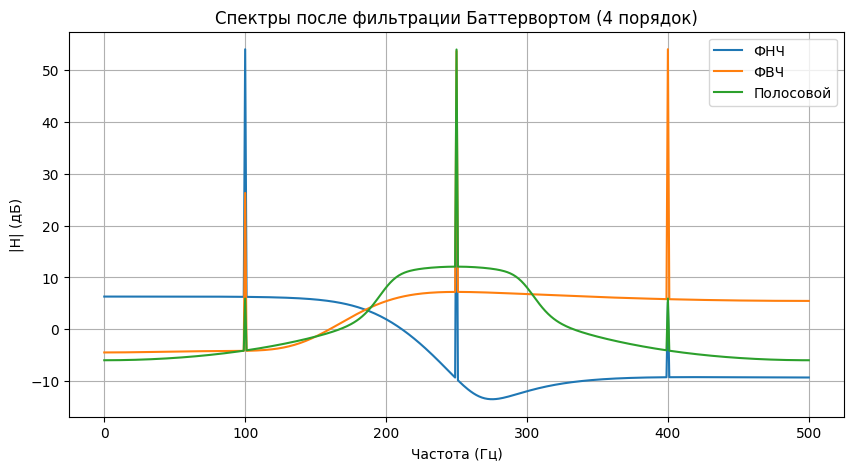

In [165]:
b_lp, a_lp = signal.butter(4, 200, btype='low', fs=fs)
b_hp, a_hp = signal.butter(4, 200, btype='high', fs=fs)
b_bp, a_bp = signal.butter(4, [200,300], btype='band', fs=fs)

x_test = np.sin(2*np.pi*100*t) + np.sin(2*np.pi*250*t) + np.sin(2*np.pi*400*t)
y_lp = signal.lfilter(b_lp, a_lp, x_test)
y_hp = signal.lfilter(b_hp, a_hp, x_test)
y_bp = signal.lfilter(b_bp, a_bp, x_test)

Y_lp = np.fft.rfft(y_lp)
Y_hp = np.fft.rfft(y_hp)
Y_bp = np.fft.rfft(y_bp)
freq = np.fft.rfftfreq(len(x_test), 1/fs)

plt.figure(figsize=(10,5))
plt.plot(freq, 20*np.log10(np.abs(Y_lp)+1e-12), label='ФНЧ')
plt.plot(freq, 20*np.log10(np.abs(Y_hp)+1e-12), label='ФВЧ')
plt.plot(freq, 20*np.log10(np.abs(Y_bp)+1e-12), label='Полосовой')
plt.title('Спектры после фильтрации Баттервортом (4 порядок)')
plt.xlabel('Частота (Гц)')
plt.ylabel('|H| (дБ)')
plt.legend(), plt.grid()
plt.show()

**Вопрос:** Какие составляющие подавлены, а какие пропущены в каждом случае?

ФНЧ пропустил только 100 Гц, ФВЧ пропустил 250 и 400 Гц, полосовой пропустил только 250 Гц.

### Задание 3.4. Применение БИХ-фильтра к зашумлённому сигналу
Сгенерируйте сигнал: синусоида 50 Гц + белый шум с дисперсией 0.2, fs=1000 Гц, длительность 1 с. Спроектируйте эллиптический ФНЧ с fc=100 Гц (порядок 6, пульсации 1 дБ, затухание 40 дБ). Примените фильтр с помощью `lfilter` и `filtfilt`. Постройте на одном графике исходный и отфильтрованные сигналы (временные области, первые 0.2 с), а также их спектры. Сравните задержку и подавление шума.


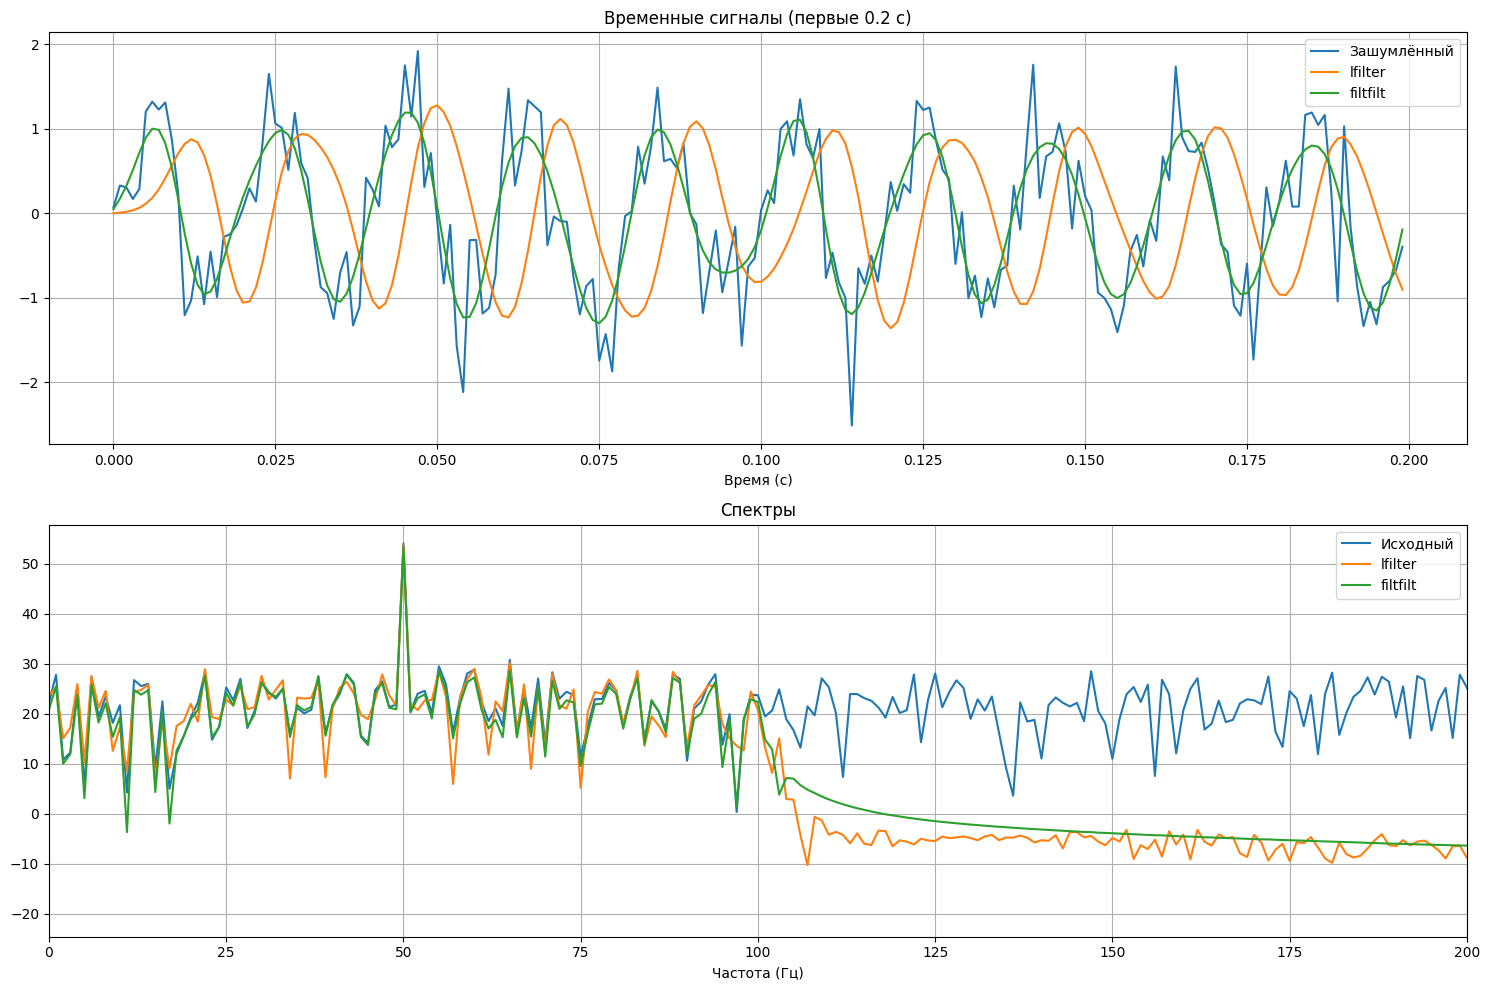

In [164]:
t = np.arange(0, 1, 1/fs)
x_sin = np.sin(2*np.pi*50*t)
noise = np.sqrt(0.2)*np.random.randn(len(t))
x_noisy = x_sin + noise

b_ell, a_ell = signal.ellip(6, 1, 40, 100, btype='low', fs=fs)
y_lf = signal.lfilter(b_ell, a_ell, x_noisy)
y_ff = signal.filtfilt(b_ell, a_ell, x_noisy)
plt.figure(figsize=(15,10))
plt.subplot(2,1,1)
plt.plot(t[:200], x_noisy[:200], label='Зашумлённый')
plt.plot(t[:200], y_lf[:200], label='lfilter')
plt.plot(t[:200], y_ff[:200], label='filtfilt')
plt.title('Временные сигналы (первые 0.2 с)')
plt.xlabel('Время (с)')
plt.legend(), plt.grid()

plt.subplot(2,1,2)
freq = np.fft.rfftfreq(len(x_noisy), 1/fs)
X = np.fft.rfft(x_noisy)
Y_lf = np.fft.rfft(y_lf)
Y_ff = np.fft.rfft(y_ff)
plt.plot(freq, 20*np.log10(np.abs(X)+1e-12), label='Исходный')
plt.plot(freq, 20*np.log10(np.abs(Y_lf)+1e-12), label='lfilter')
plt.plot(freq, 20*np.log10(np.abs(Y_ff)+1e-12), label='filtfilt')
plt.title('Спектры')
plt.xlabel('Частота (Гц)')
plt.xlim(0, 200)
plt.legend(), plt.grid()
plt.tight_layout()
plt.show()

**Вопрос:** Почему `filtfilt` даёт нулевой фазовый сдвиг?

filtfilt прогоняет сигнал в обе стороны, поэтому фаза обнуляется

## Часть 4. Сравнение КИХ и БИХ фильтров одинакового порядка

### Задание 4.1. Сравнение характеристик
Спроектируйте:
- КИХ-ФНЧ методом окон (окно Хемминга, длина 51, fc=200 Гц);
- БИХ-ФНЧ Баттерворта 4-го порядка (fc=200 Гц).

Постройте для них на одном графике:
- отдельно АЧХ (в дБ),
- отдельно групповую задержку.


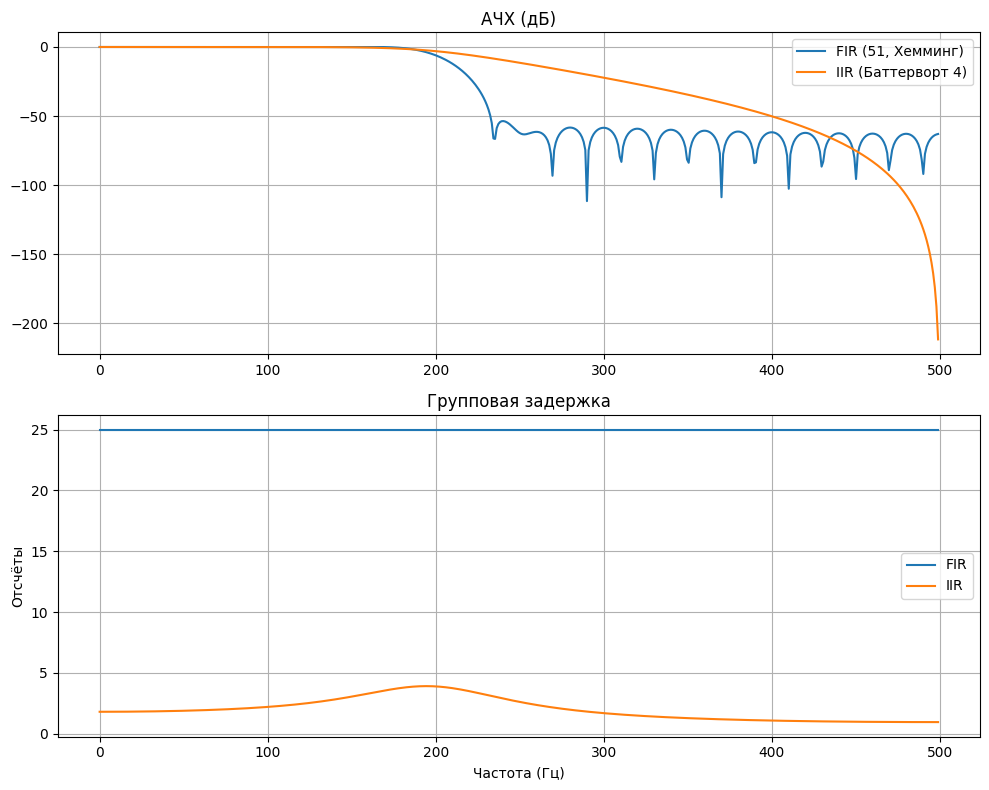

In [176]:
h_fir = signal.firwin(51, 200, window='hamming', fs=fs)
b_iir, a_iir = signal.butter(4, 200, btype='low', fs=fs)

w, H_fir = signal.freqz(h_fir, 1, fs=fs)
w, H_iir = signal.freqz(b_iir, a_iir, fs=fs)

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(w, 20*np.log10(np.abs(H_fir)+1e-12), label='FIR (51, Хемминг)')
plt.plot(w, 20*np.log10(np.abs(H_iir)+1e-12), label='IIR (Баттерворт 4)')
plt.title('АЧХ (дБ)')
plt.legend(), plt.grid()

plt.subplot(2,1,2)
w_g, gd_fir = signal.group_delay((h_fir, 1), fs=fs)
w_g, gd_iir = signal.group_delay((b_iir, a_iir), fs=fs)
plt.plot(w_g, gd_fir, label='FIR')
plt.plot(w_g, gd_iir, label='IIR')
plt.title('Групповая задержка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Отсчёты')
plt.legend(), plt.grid()
plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр имеет более крутой срез? Какой имеет постоянную групповую задержку? Какой вносит меньшие фазовые искажения? Какой требует меньше вычислений? Попробуйте увеличить порядок фильтра Баттерворта. При каком порядке крутизна среза его АЧХ становится сравнимой с КИХ-фильтром? Растут или уменьшаются при этом фазовые искажения?


Круче срез у КИХ.

Постоянная групповая задержка у КИХ.

Меньше фазовых искажений у КИХ.

Меньше вычислений у БИХ.

Чтобы Баттерворт догнал КИХ по крутизне, нужен порядок больше 15.

С ростом порядка фазовые искажения растут.


### Задание 4.2. Применение к реальному сигналу
Сгенерируйте сигнал: короткий прямоугольный импульс длительностью 10 мс, а также высокочастотная синусоидальная помеха 400 Гц. Частоту дискретизации возьмите fs=10000 Гц.

Примените оба фильтра (КИХ и БИХ из предыдущего пункта). Постройте исходный и отфильтрованные сигналы.


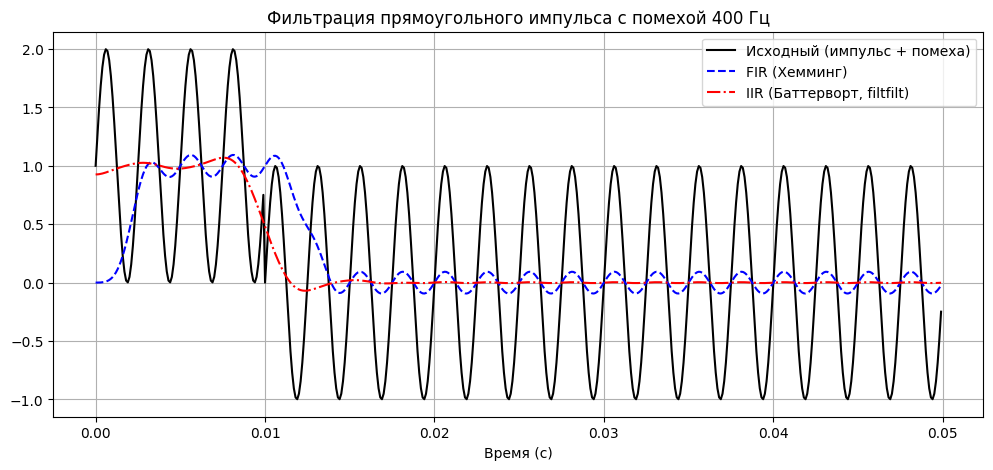

In [152]:
fs2 = 10000
t = np.arange(0, 0.1, 1/fs2)
pulse = np.zeros(len(t))
pulse[:100] = 1
interf = np.sin(2*np.pi*400*t)
x_pulse = pulse + interf

h_fir2 = signal.firwin(51, 200, window='hamming', fs=fs2)
b_iir2, a_iir2 = signal.butter(4, 200, btype='low', fs=fs2)

y_fir = signal.lfilter(h_fir2, 1, x_pulse)
y_iir = signal.filtfilt(b_iir2, a_iir2, x_pulse)

plt.figure(figsize=(12,5))
plt.plot(t[:500], x_pulse[:500], 'k', label='Исходный (импульс + помеха)')
plt.plot(t[:500], y_fir[:500], 'b--', label='FIR (Хемминг)')
plt.plot(t[:500], y_iir[:500], 'r-.', label='IIR (Баттерворт, filtfilt)')
plt.title('Фильтрация прямоугольного импульса с помехой 400 Гц')
plt.xlabel('Время (с)')
plt.legend()
plt.grid()
plt.show()

**Вопросы:** Какой фильтр лучше сохранил форму импульсов? Какой лучше подавил помеху?

Форму импульса лучше сохранил КИХ, потому что у него линейная фаза, импульс только сдвигается по времени.

Помеху 400 Гц оба хорошо подавили помеху, но БИХ чуть лучше.